# 02 — Nettoyage et préparation des données

**Entrée** : `data/processed/chomage_mensuel.csv` (généré par notebook 01)  
**Sortie** : Données formatées pour Prophet et ARIMA

## Étapes
1. Chargement et validation des données nettoyées
2. Gestion des valeurs manquantes
3. Séparation train/test (80/20)
4. Préparation du format Prophet (ds, y)
5. Préparation du format ARIMA (série temporelle indexée)
6. Sauvegarde des datasets prêts pour la modélisation

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils import PROVINCES, PROVINCES_FR, DATA_PROCESSED, prepare_prophet_df

plt.style.use('seaborn-v0_8-whitegrid')
print('Imports OK')

Imports OK


## 1. Chargement et validation

In [2]:
# Charger les donnees filtrees du notebook 01
df = pd.read_csv(DATA_PROCESSED / 'chomage_mensuel.csv', parse_dates=['date'])

print(f"Shape : {df.shape}")
print(f"Dtypes :\n{df.dtypes}")
print(f"\nValeurs manquantes :\n{df.isna().sum()}")
print(f"\nPeriode : {df['date'].min()} a {df['date'].max()}")
print(f"Geographies : {sorted(df['geo'].unique())}")

Shape : (6688, 3)
Dtypes :
date                 datetime64[us]
geo                             str
unemployment_rate           float64
dtype: object

Valeurs manquantes :
date                 0
geo                  0
unemployment_rate    0
dtype: int64

Periode : 1976-01-01 00:00:00 a 2026-08-01 00:00:00
Geographies : ['Alberta', 'British Columbia', 'Canada', 'Manitoba', 'New Brunswick', 'Newfoundland and Labrador', 'Nova Scotia', 'Ontario', 'Prince Edward Island', 'Quebec', 'Saskatchewan']


In [3]:
# Verifier la continuite temporelle (pas de mois manquants)
for geo in df['geo'].unique():
    subset = df[df['geo'] == geo].sort_values('date')
    date_range = pd.date_range(subset['date'].min(), subset['date'].max(), freq='MS')
    missing_dates = date_range.difference(subset['date'])
    if len(missing_dates) > 0:
        print(f"ATTENTION — {geo} : {len(missing_dates)} mois manquants")
        print(f"  Dates : {missing_dates.tolist()[:5]}...")
    else:
        print(f"{geo} : serie complete ({len(subset)} mois)")

Alberta : serie complete (608 mois)
British Columbia : serie complete (608 mois)
Canada : serie complete (608 mois)
Manitoba : serie complete (608 mois)
New Brunswick : serie complete (608 mois)
Newfoundland and Labrador : serie complete (608 mois)
Nova Scotia : serie complete (608 mois)
Ontario : serie complete (608 mois)
Prince Edward Island : serie complete (608 mois)
Quebec : serie complete (608 mois)
Saskatchewan : serie complete (608 mois)


## 2. Gestion des valeurs manquantes

Si des valeurs sont manquantes, on utilise une interpolation linéaire (appropriée pour des séries mensuelles continues).

In [4]:
# Interpolation lineaire si necessaire
na_count = df['unemployment_rate'].isna().sum()
if na_count > 0:
    print(f"Interpolation de {na_count} valeurs manquantes...")
    df['unemployment_rate'] = df.groupby('geo')['unemployment_rate'].transform(
        lambda x: x.interpolate(method='linear')
    )
    print(f"Valeurs manquantes apres interpolation : {df['unemployment_rate'].isna().sum()}")
else:
    print("Aucune valeur manquante — pas d'interpolation necessaire.")

Aucune valeur manquante — pas d'interpolation necessaire.


## 3. Séparation train/test

**Stratégie** : On garde les **12 derniers mois** comme ensemble de test.  
Cela permet d'évaluer la capacité prédictive des modèles sur un horizon de 12 mois,  
tout en conservant un maximum de données pour l'entraînement.

In [5]:
# Definir le point de coupure : 12 derniers mois = test
HORIZON = 12  # mois
cutoff_date = df['date'].max() - pd.DateOffset(months=HORIZON)

print(f"Date de coupure : {cutoff_date.strftime('%Y-%m-%d')}")
print(f"Train : avant {cutoff_date.strftime('%Y-%m')}")
print(f"Test  : {cutoff_date.strftime('%Y-%m')} a {df['date'].max().strftime('%Y-%m')} ({HORIZON} mois)")

df_train = df[df['date'] <= cutoff_date].copy()
df_test = df[df['date'] > cutoff_date].copy()

print(f"\nTrain : {df_train.shape[0]} observations")
print(f"Test  : {df_test.shape[0]} observations")

Date de coupure : 2025-08-01
Train : avant 2025-08
Test  : 2025-08 a 2026-08 (12 mois)

Train : 6556 observations
Test  : 132 observations


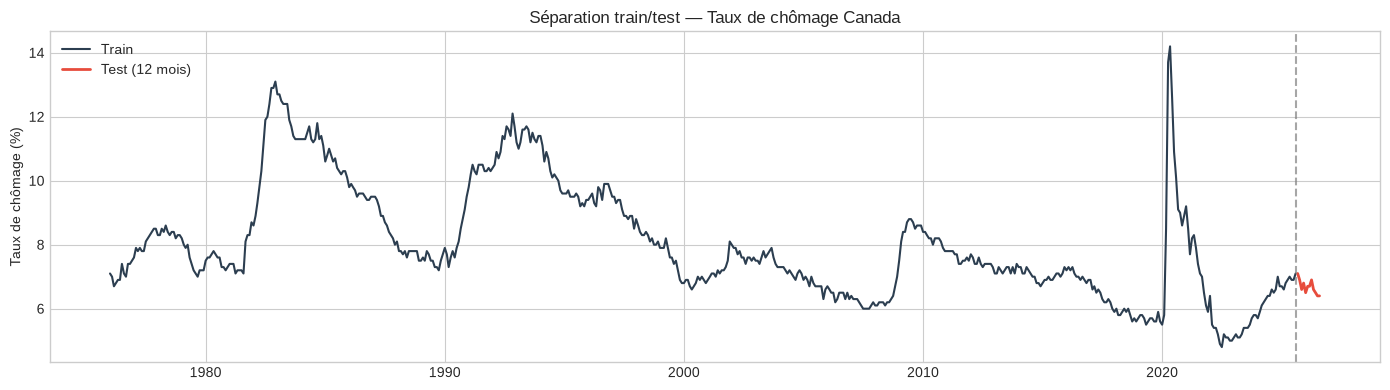

In [6]:
# Visualiser la coupure pour le Canada
canada_train = df_train[df_train['geo'] == 'Canada']
canada_test = df_test[df_test['geo'] == 'Canada']

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(canada_train['date'], canada_train['unemployment_rate'],
        color='#2c3e50', label='Train')
ax.plot(canada_test['date'], canada_test['unemployment_rate'],
        color='#e74c3c', linewidth=2, label='Test (12 mois)')
ax.axvline(cutoff_date, color='gray', linestyle='--', alpha=0.7)
ax.set_title('Séparation train/test — Taux de chômage Canada')
ax.set_ylabel('Taux de chômage (%)')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Préparation des formats Prophet et ARIMA

In [7]:
# Format Prophet : un fichier par geographie (ds, y)
# Format ARIMA : serie temporelle avec index DatetimeIndex et frequence mensuelle

geos = ['Canada'] + sorted(PROVINCES)

prophet_data = {}
arima_data = {}

for geo in geos:
    # Prophet format
    prophet_train = prepare_prophet_df(df_train, geo)
    prophet_test = prepare_prophet_df(df_test, geo)
    prophet_data[geo] = {'train': prophet_train, 'test': prophet_test}
    
    # ARIMA format : serie indexee par date avec frequence MS (month start)
    arima_train = (df_train[df_train['geo'] == geo]
                   .set_index('date')['unemployment_rate']
                   .asfreq('MS'))
    arima_test = (df_test[df_test['geo'] == geo]
                  .set_index('date')['unemployment_rate']
                  .asfreq('MS'))
    arima_data[geo] = {'train': arima_train, 'test': arima_test}

# Verification
print("Canada — Prophet train :")
print(prophet_data['Canada']['train'].tail(3))
print(f"\nCanada — ARIMA train (freq={arima_data['Canada']['train'].index.freq}) :")
print(arima_data['Canada']['train'].tail(3))

Canada — Prophet train :
            ds    y
593 2025-06-01  6.9
594 2025-07-01  6.9
595 2025-08-01  7.1

Canada — ARIMA train (freq=<MonthBegin>) :
date
2025-06-01    6.9
2025-07-01    6.9
2025-08-01    7.1
Freq: MS, Name: unemployment_rate, dtype: float64


## 5. Sauvegarde

In [8]:
# Sauvegarder les datasets train/test
df_train.to_csv(DATA_PROCESSED / 'chomage_train.csv', index=False)
df_test.to_csv(DATA_PROCESSED / 'chomage_test.csv', index=False)

# Sauvegarder les metadonnees de la separation
meta = {
    'cutoff_date': cutoff_date.strftime('%Y-%m-%d'),
    'horizon_months': HORIZON,
    'train_obs': len(df_train),
    'test_obs': len(df_test),
    'geographies': geos
}
pd.Series(meta).to_json(DATA_PROCESSED / 'split_metadata.json')

print("Fichiers sauvegardes :")
print(f"  - {DATA_PROCESSED / 'chomage_train.csv'}")
print(f"  - {DATA_PROCESSED / 'chomage_test.csv'}")
print(f"  - {DATA_PROCESSED / 'split_metadata.json'}")
print(f"\nPret pour la modelisation!")

Fichiers sauvegardes :
  - /home/runner/work/forecasting-chomage-canada/forecasting-chomage-canada/data/processed/chomage_train.csv
  - /home/runner/work/forecasting-chomage-canada/forecasting-chomage-canada/data/processed/chomage_test.csv
  - /home/runner/work/forecasting-chomage-canada/forecasting-chomage-canada/data/processed/split_metadata.json

Pret pour la modelisation!


---
*Prochaine étape → Notebook 03 : Modélisation ARIMA et Prophet + comparaison.*